# Архитектура Transformer для классификации тональности русскоязычных текстов

В этом блокноте мы построим и обучим модель на основе архитектуры **Transformer Encoder** для задачи классификации тональности русскоязычных текстов.

Используем:

- токенизатор: `cointegrated/rubert-tiny2`;
- датасет: `sepidmnorozy/Russian_sentiment`;
- фреймворк: `TensorFlow / Keras`;
- стиль построения модели: **только Functional API Keras, без пользовательских классов**.

Цель занятия: понять основные идеи трансформера и увидеть полный практический пайплайн решения NLP-задачи: от токенизации до оценки качества модели.

## План занятия

Задача формулируется как supervised learning:

$$
f_\theta(x) \rightarrow y,
$$

где:

- $x$ — входной текст на русском языке;
- $y$ — метка тональности;
- $f_\theta$ — нейронная модель с параметрами $\theta$.

## 1. Теоретическая основа: зачем нужен Transformer

До трансформеров в NLP часто использовали рекуррентные сети: RNN, LSTM, GRU. Они обрабатывают последовательность слева направо или справа налево. Это удобно, но плохо параллелится и затрудняет моделирование дальних зависимостей.

Transformer заменяет рекуррентность механизмом **attention**:

$$
\mathrm{Attention}(Q, K, V) =
\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}\right)V.
$$

Здесь:

- $Q$ — queries, матрица запросов;
- $K$ — keys, матрица ключей;
- $V$ — values, матрица значений;
- $d_k$ — размерность ключей, используется для стабилизации масштаба скалярных произведений.

Интуитивно attention отвечает на вопрос:

> На какие токены входного текста должен смотреть каждый токен, чтобы получить более информативное представление?

## 2. Multi-Head Attention

Одна attention-голова может выучить один тип отношений между токенами. Multi-Head Attention использует несколько голов:

$$
\mathrm{head}_i =
\mathrm{Attention}(QW_i^Q, KW_i^K, VW_i^V),
$$

$$
\mathrm{MultiHead}(Q,K,V) =
\mathrm{Concat}(\mathrm{head}_1,\ldots,\mathrm{head}_h)W^O.
$$

Разные головы могут специализироваться на разных признаках:

- синтаксические связи;
- отрицания;
- эмоционально окрашенные слова;
- отношения между соседними и удаленными словами.

В задаче тональности это особенно важно: фраза “не очень хороший” не равна сумме слов “очень” и “хороший”.

## 3. Transformer Encoder

Один encoder-блок обычно содержит:

1. Multi-Head Self-Attention;
2. residual connection;
3. Layer Normalization;
4. Feed-Forward Network;
5. еще одну residual connection;
6. еще одну Layer Normalization.

Схематически:

$$
Z_1 = \mathrm{LayerNorm}(X + \mathrm{MHA}(X,X,X)),
$$

$$
Z_2 = \mathrm{LayerNorm}(Z_1 + \mathrm{FFN}(Z_1)).
$$

В этом блокноте мы построим encoder через стандартные слои Keras и обычные функции Python. Пользовательские классы слоев использовать не будем.

## 4. Установка и импорт библиотек

Если зависимости уже установлены, ячейка быстро завершится.

Нам нужны:

- `tensorflow` — построение и обучение модели;
- `transformers` — загрузка Hugging Face токенизатора;
- `datasets` — загрузка датасета;
- `scikit-learn` — train/validation split и отчет по метрикам;
- `matplotlib` — графики обучения.

In [2]:
# Базовые библиотеки Python.
import os
import random
from collections import Counter

# Научный стек.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# TensorFlow и Keras.
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Hugging Face: датасеты и токенизаторы.
from datasets import load_dataset
from transformers import AutoTokenizer

# Метрики и разбиение данных.
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


# Константы проекта.
# TOKENIZER_NAME: имя предобученного токенизатора в Hugging Face Hub.
# DATASET_NAME: имя датасета в Hugging Face Hub.
TOKENIZER_NAME = "cointegrated/rubert-tiny2"
DATASET_NAME = "sepidmnorozy/Russian_sentiment"


# SEED нужен, чтобы результаты были более воспроизводимыми.
SEED = 42


def set_global_seed(seed):
    """
    Фиксирует генераторы случайных чисел в Python, NumPy и TensorFlow.

    Аргументы:
        seed: целое число, начальное значение генератора случайных чисел.

    Возвращает:
        None. Функция меняет глобальное состояние генераторов.
    """
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)


set_global_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

I0000 00:00:1779799003.663633 3429650 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1779799003.692639 3429650 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1779799004.362855 3429650 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


W0000 00:00:1779799007.322436 3429650 gpu_device.cc:2459] TensorFlow was not built with CUDA kernel binaries compatible with compute capability 12.0a. CUDA kernels will be jit-compiled from PTX, which could take 30 minutes or longer.


## 5. Загрузка датасета

Загрузим датасет `sepidmnorozy/Russian_sentiment` и посмотрим на его структуру.

У разных датасетов Hugging Face могут отличаться названия колонок. Поэтому ниже есть небольшая функция, которая пытается автоматически найти:

- текстовую колонку;
- колонку с меткой класса.

In [3]:
raw_dataset = load_dataset(DATASET_NAME)
raw_dataset

DatasetDict({
    train: Dataset({
        features: ['label', 'text'],
        num_rows: 2938
    })
    validation: Dataset({
        features: ['label', 'text'],
        num_rows: 424
    })
    test: Dataset({
        features: ['label', 'text'],
        num_rows: 867
    })
})

In [4]:
def choose_column(column_names, candidates):
    """
    Выбирает первую подходящую колонку из списка кандидатов.

    Аргументы:
        column_names: список реальных названий колонок в датасете.
        candidates: список ожидаемых названий колонок, например ["text", "label"].

    Возвращает:
        Строку с названием найденной колонки.
    """
    for name in candidates:
        if name in column_names:
            return name
    raise ValueError(f"Не удалось найти колонку среди кандидатов: {candidates}. Доступные колонки: {column_names}")


def dataset_split_to_dataframe(dataset_dict):
    """
    Преобразует Hugging Face DatasetDict в один pandas DataFrame.

    Аргументы:
        dataset_dict: объект DatasetDict, возвращенный функцией load_dataset.

    Возвращает:
        DataFrame со всеми примерами из доступных split-частей.
        Дополнительно добавляет колонку split, чтобы было видно происхождение строк.
    """
    frames = []

    for split_name, split_data in dataset_dict.items():
        frame = split_data.to_pandas()
        frame["split"] = split_name
        frames.append(frame)

    return pd.concat(frames, ignore_index=True)


df = dataset_split_to_dataframe(raw_dataset)

TEXT_COLUMN = choose_column(
    df.columns,
    candidates=["text", "sentence", "review", "content", "comment", "tweet"]
)

LABEL_COLUMN = choose_column(
    df.columns,
    candidates=["label", "labels", "sentiment", "class", "target"]
)

print("Текстовая колонка:", TEXT_COLUMN)
print("Колонка метки:", LABEL_COLUMN)
print("Размер датасета:", df.shape)

df.head()

Текстовая колонка: text
Колонка метки: label
Размер датасета: (4229, 3)


,label,text,split
0,0,Досудебное расследование по факту покупки ЕНПФ...,train
1,0,Медики рассказали о состоянии пострадавшего му...,train
2,0,"Прошел почти год , как железнодорожным операто...",train
3,0,По итогам 12 месяцев 2016 года на территории р...,train
4,0,Астана . 21 ноября . Kazakhstan Today - Агентс...,train


In [5]:
# Оставляем только нужные колонки и удаляем пропуски.
df = df[[TEXT_COLUMN, LABEL_COLUMN]].dropna().copy()

# Приводим тексты к строковому типу.
df[TEXT_COLUMN] = df[TEXT_COLUMN].astype(str)

print("Размер после удаления пропусков:", df.shape)
print("Примеры меток:", df[LABEL_COLUMN].unique()[:20])
print("Распределение классов:")
display(df[LABEL_COLUMN].value_counts())

Размер после удаления пропусков: (4229, 2)
Примеры меток: [0 1]
Распределение классов:


label
1    2795
0    1434
Name: count, dtype: int64

## 6. Кодирование меток

Нейронная сеть не работает напрямую со строковыми метками. Поэтому переведем классы в числа:

$$
y \in \{0, 1, \ldots, C-1\},
$$

где $C$ — число классов.

Если в датасете метки уже числовые, мы все равно построим явное отображение `label_to_id`, чтобы вывод модели можно было интерпретировать.

In [6]:
def build_label_maps(labels):
    """
    Строит отображения между исходными метками и числовыми идентификаторами.

    Аргументы:
        labels: одномерная последовательность исходных меток классов.

    Возвращает:
        label_to_id: словарь {исходная_метка: числовой_id}.
        id_to_label: словарь {числовой_id: исходная_метка}.
    """
    unique_labels = sorted(pd.Series(labels).unique().tolist(), key=lambda value: str(value))
    label_to_id = {label: index for index, label in enumerate(unique_labels)}
    id_to_label = {index: label for label, index in label_to_id.items()}
    return label_to_id, id_to_label


label_to_id, id_to_label = build_label_maps(df[LABEL_COLUMN])
df["label_id"] = df[LABEL_COLUMN].map(label_to_id).astype("int32")

NUM_CLASSES = len(label_to_id)

print("Количество классов:", NUM_CLASSES)
print("label_to_id:", label_to_id)
display(df.head())

Количество классов: 2
label_to_id: {0: 0, 1: 1}


,text,label,label_id
0,Досудебное расследование по факту покупки ЕНПФ...,0,0
1,Медики рассказали о состоянии пострадавшего му...,0,0
2,"Прошел почти год , как железнодорожным операто...",0,0
3,По итогам 12 месяцев 2016 года на территории р...,0,0
4,Астана . 21 ноября . Kazakhstan Today - Агентс...,0,0


## 7. Train/Validation/Test split

Разделим данные на три части:

- train — обучение параметров модели;
- validation — контроль качества во время обучения;
- test — финальная проверка после выбора модели.

Используем стратификацию, чтобы сохранить пропорции классов:

$$
P(y=c \mid \mathrm{train}) \approx P(y=c \mid \mathrm{test}).
$$

In [7]:
texts = df[TEXT_COLUMN].to_numpy()
labels = df["label_id"].to_numpy()

# Сначала отделяем тестовую выборку.
texts_trainval, texts_test, y_trainval, y_test = train_test_split(
    texts,
    labels,
    test_size=0.15,
    random_state=SEED,
    stratify=labels,
)

# Затем из оставшейся части выделяем validation.
texts_train, texts_val, y_train, y_val = train_test_split(
    texts_trainval,
    y_trainval,
    test_size=0.15,
    random_state=SEED,
    stratify=y_trainval,
)

print("Train:", len(texts_train))
print("Validation:", len(texts_val))
print("Test:", len(texts_test))

Train: 3054
Validation: 540
Test: 635


## 8. Токенизация

Трансформер работает не с текстом напрямую, а с последовательностями токенов.

Мы используем токенизатор `cointegrated/rubert-tiny2`. Он разбивает русскоязычный текст на subword-токены и возвращает:

- `input_ids` — числовые идентификаторы токенов;
- `attention_mask` — маску, где 1 означает реальный токен, а 0 означает padding.

Для батчевой обработки все последовательности приводятся к одной длине `MAX_LENGTH`.

In [8]:
tokenizer = AutoTokenizer.from_pretrained(TOKENIZER_NAME)

# MAX_LENGTH ограничивает длину входной последовательности.
MAX_LENGTH = 96


def tokenize_texts(texts, tokenizer, max_length):
    """
    Токенизирует массив текстов для подачи в Keras-модель.

    Аргументы:
        texts: список или numpy-массив строк.
        tokenizer: объект Hugging Face tokenizer с методом __call__.
        max_length: максимальная длина последовательности после токенизации.

    Возвращает:
        Словарь с двумя numpy-массивами:
            input_ids: идентификаторы токенов, shape = (num_examples, max_length).
            attention_mask: маска реальных токенов, shape = (num_examples, max_length).
    """
    encoded = tokenizer(
        list(texts),
        padding="max_length",
        truncation=True,
        max_length=max_length,
        return_tensors="np",
    )

    return {
        "input_ids": encoded["input_ids"].astype("int32"),
        "attention_mask": encoded["attention_mask"].astype("int32"),
    }


train_tokens = tokenize_texts(texts_train, tokenizer, MAX_LENGTH)
val_tokens = tokenize_texts(texts_val, tokenizer, MAX_LENGTH)
test_tokens = tokenize_texts(texts_test, tokenizer, MAX_LENGTH)

print("input_ids shape:", train_tokens["input_ids"].shape)
print("attention_mask shape:", train_tokens["attention_mask"].shape)

input_ids shape: (3054, 96)
attention_mask shape: (3054, 96)


In [9]:
example_index = 0
example_text = texts_train[example_index]
example_ids = train_tokens["input_ids"][example_index]
example_tokens = tokenizer.convert_ids_to_tokens(example_ids)

print("Исходный текст:")
print(example_text)
print()
print("Первые 30 token ids:")
print(example_ids[:30])
print()
print("Первые 30 токенов:")
print(example_tokens[:30])

Исходный текст:
Усть - Катав , Челябинская область , 3 Октября 2016 , 14 : 32 — REGNUM Победителем крупнейшего тендера на поставку 300 трамвайных вагонов , объявленного ' Мосгортрансом ' , стал ' Метровагонмаш ' , дочернее предприятие ' Трансмашхолдинга ' . В конкурсе также участвовали Усть - Катавский вагоностроительный завод ( УКВЗ ) и предприятие ' Штадлер Минск ' . Сумма заключенного контракта составила 56 млрд рублей : 300 трехсекционных трамваев будут поставлены в Москву в 2017 — 2019 гг . ( по 100 штук в год ) с обязательством их обслуживания в течение 30 лет , передает корреспондент ИА REGNUM . Базовой площадкой для производства станет Тверской вагоностроительный завод . Акционером ' Трансмашхолдинга ' , владеющим 100 % акций , является нидерландский холдинг The Breakers Investments B.V . О сложностях в подготовке к конкурсу ранее заявлял директор УКВЗ Александр Гнатюк : ' Конечно , мы намерены участвовать в этом конкурсе , но его организаторы прописали ряд ограничений , не поз

## 9. Создание `tf.data.Dataset`

`tf.data` позволяет эффективно подавать данные в модель батчами.

Каждый элемент датасета будет иметь вид:

```python
(
    {"input_ids": ..., "attention_mask": ...},
    label
)
```

Имена входов должны совпадать с именами keras.Input в модели.

In [13]:
BATCH_SIZE = 32


def make_tf_dataset(tokens, labels, batch_size, shuffle=False):
    """
    Создает tf.data.Dataset для обучения или оценки модели.

    Аргументы:
        tokens: словарь с массивами input_ids и attention_mask.
        labels: numpy-массив числовых меток.
        batch_size: размер батча.
        shuffle: перемешивать ли примеры. Обычно True для train и False для validation/test.

    Возвращает:
        Объект tf.data.Dataset с батчами данных.
    """
    features = {
        "input_ids": tokens["input_ids"],
        "attention_mask": tokens["attention_mask"],
    }

    dataset = tf.data.Dataset.from_tensor_slices((features, labels.astype("int32")))

    if shuffle:
        dataset = dataset.shuffle(buffer_size=len(labels), seed=SEED, reshuffle_each_iteration=True)

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)

    return dataset


train_ds = make_tf_dataset(train_tokens, y_train, BATCH_SIZE, shuffle=True)
val_ds = make_tf_dataset(val_tokens, y_val, BATCH_SIZE, shuffle=False)
test_ds = make_tf_dataset(test_tokens, y_test, BATCH_SIZE, shuffle=False)

for batch_features, batch_labels in train_ds.take(1):
    print(batch_features["input_ids"].shape)
    print(batch_features["attention_mask"].shape)
    print(batch_labels.shape)

(32, 96)
(32, 96)
(32,)


## 10. Построение Transformer Encoder

Важные компоненты:

### Token Embedding

Каждый токен получает обучаемый вектор:

$$
x_i = E[\mathrm{token}_i].
$$

### Positional Embedding

Self-attention не знает порядок токенов сам по себе, поэтому добавляем позиционные векторы:

$$
h_i^{(0)} = E[\mathrm{token}_i] + P[i].
$$

### Padding mask

Padding-токены не должны влиять на attention. Для этого используем `attention_mask`.

In [26]:
import tensorflow as tf
from keras import layers


def add_token_and_position_embeddings(
    input_ids, vocab_size, max_length, embed_dim
):
    """Создает сумму token embeddings и positional embeddings.

    Аргументы:
        input_ids: KerasTensor с token ids, shape = (batch_size, max_length).
        vocab_size: размер словаря токенизатора.
        max_length: максимальная длина последовательности.
        embed_dim: размерность векторного представления токена.

    Возвращает:
        KerasTensor shape = (batch_size, max_length, embed_dim).
    """
    # 1. Получаем эмбеддинги токенов: shape = (batch_size, max_length, embed_dim)
    token_embeddings = layers.Embedding(
        input_dim=vocab_size,
        output_dim=embed_dim,
        name="token_embedding",
    )(input_ids)

    # 2. Генерируем вектор позиций: shape = (max_length,)
    positions = tf.range(start=0, limit=max_length, delta=1)

    # 3. Получаем позиционные эмбеддинги: shape = (max_length, embed_dim)
    position_embeddings = layers.Embedding(
        input_dim=max_length,
        output_dim=embed_dim,
        name="position_embedding",
    )(positions)

    # 4. Складываем через оператор "+".
    # Бродкастинг автоматически прибавит (max_length, embed_dim) к каждому батчу.
    return token_embeddings + position_embeddings



def transformer_encoder_block(x, attention_mask, embed_dim, num_heads, ff_dim, dropout_rate, block_index):
    """
    Добавляет один Transformer Encoder block.

    Аргументы:
        x: входной KerasTensor shape = (batch_size, seq_len, embed_dim).
        attention_mask: KerasTensor shape = (batch_size, seq_len), где 1 — реальный токен, 0 — padding.
        embed_dim: размерность скрытого представления.
        num_heads: количество attention-голов.
        ff_dim: размерность внутреннего слоя feed-forward сети.
        dropout_rate: вероятность dropout.
        block_index: номер блока, используется только для уникальных имен слоев.

    Возвращает:
        KerasTensor с той же формой, что и x.
    """
    # MultiHeadAttention ожидает attention_mask, которую можно привести к форме
    # (batch_size, query_length, key_length). Здесь каждая позиция query видит
    # только реальные key-токены, а padding игнорируется.
    expanded_mask = layers.Lambda(
        lambda m, **kwargs: tf.cast(m[:, tf.newaxis, :], tf.bool),
        name=f"expand_attention_mask_{block_index}",
    )(attention_mask)

    attention_output = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=embed_dim // num_heads,
        dropout=dropout_rate,
        name=f"multi_head_attention_{block_index}",
    )(
        query=x,
        value=x,
        key=x,
        attention_mask=expanded_mask,
    )

    attention_output = layers.Dropout(
        rate=dropout_rate,
        name=f"attention_dropout_{block_index}",
    )(attention_output)

    x = layers.Add(name=f"attention_residual_{block_index}")([x, attention_output])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"attention_norm_{block_index}")(x)

    ffn_output = layers.Dense(ff_dim, activation="gelu", name=f"ffn_dense_1_{block_index}")(x)
    ffn_output = layers.Dropout(rate=dropout_rate, name=f"ffn_dropout_{block_index}")(ffn_output)
    ffn_output = layers.Dense(embed_dim, name=f"ffn_dense_2_{block_index}")(ffn_output)

    x = layers.Add(name=f"ffn_residual_{block_index}")([x, ffn_output])
    x = layers.LayerNormalization(epsilon=1e-6, name=f"ffn_norm_{block_index}")(x)

    return x


def masked_average_pooling(sequence_output, attention_mask):
    """
    Усредняет представления токенов, игнорируя padding.

    Аргументы:
        sequence_output: KerasTensor shape = (batch_size, seq_len, hidden_dim).
        attention_mask: KerasTensor shape = (batch_size, seq_len), где 1 — реальный токен.

    Возвращает:
        KerasTensor shape = (batch_size, hidden_dim).
    """
    mask = layers.Lambda(
        lambda values: tf.cast(values[:, :, tf.newaxis], tf.float32),
        name="pooling_mask_float",
    )(attention_mask)

    masked_sequence = layers.Multiply(name="apply_pooling_mask")([sequence_output, mask])

    token_sum = layers.Lambda(
        lambda values: tf.reduce_sum(values, axis=1),
        name="sum_real_tokens",
    )(masked_sequence)

    token_count = layers.Lambda(
        lambda values: tf.reduce_sum(values, axis=1) + 1e-9,
        name="count_real_tokens",
    )(mask)

    return token_sum / token_count

## 11. Сборка модели

Финальная архитектура:

1. `input_ids`, `attention_mask`;
2. token + positional embeddings;
3. несколько Transformer Encoder blocks;
4. masked average pooling;
5. dense classifier.

Для многоклассовой классификации используем softmax:

$$
p(y=c \mid x) =
\frac{\exp(z_c)}{\sum_{j=1}^{C}\exp(z_j)}.
$$

Функция потерь:

$$
\mathcal{L} = -\log p(y_{\mathrm{true}} \mid x).
$$

In [27]:
def build_transformer_classifier(
    vocab_size,
    max_length,
    num_classes,
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    dropout_rate=0.2,
    learning_rate=3e-4,
):
    """
    Строит модель Transformer Encoder для классификации текста.

    Аргументы:
        vocab_size: размер словаря токенизатора.
        max_length: максимальная длина входной последовательности.
        num_classes: количество классов.
        embed_dim: размерность token/position embeddings.
        num_heads: количество голов self-attention.
        ff_dim: размерность скрытого слоя feed-forward network.
        num_layers: количество encoder-блоков.
        dropout_rate: dropout для регуляризации.
        learning_rate: скорость обучения оптимизатора AdamW.

    Возвращает:
        Скомпилированную keras.Model.
    """
    input_ids = keras.Input(shape=(max_length,), dtype="int32", name="input_ids")
    attention_mask = keras.Input(shape=(max_length,), dtype="int32", name="attention_mask")

    x = add_token_and_position_embeddings(
        input_ids=input_ids,
        vocab_size=vocab_size,
        max_length=max_length,
        embed_dim=embed_dim,
    )

    x = layers.Dropout(rate=dropout_rate, name="embedding_dropout")(x)

    for block_index in range(num_layers):
        x = transformer_encoder_block(
            x=x,
            attention_mask=attention_mask,
            embed_dim=embed_dim,
            num_heads=num_heads,
            ff_dim=ff_dim,
            dropout_rate=dropout_rate,
            block_index=block_index + 1,
        )

    x = masked_average_pooling(x, attention_mask)
    x = layers.Dropout(rate=dropout_rate, name="classifier_dropout")(x)
    x = layers.Dense(128, activation="gelu", name="classifier_dense")(x)
    x = layers.Dropout(rate=dropout_rate, name="classifier_dropout_2")(x)

    outputs = layers.Dense(num_classes, activation="softmax", name="class_probabilities")(x)

    model = keras.Model(
        inputs={"input_ids": input_ids, "attention_mask": attention_mask},
        outputs=outputs,
        name="functional_transformer_sentiment_classifier",
    )

    optimizer = keras.optimizers.AdamW(
        learning_rate=learning_rate,
        weight_decay=1e-4,
    )

    model.compile(
        optimizer=optimizer,
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )

    return model


# len(tokenizer) учитывает не только базовый словарь, но и специальные добавленные токены.
VOCAB_SIZE = len(tokenizer)

model = build_transformer_classifier(
    vocab_size=VOCAB_SIZE,
    max_length=MAX_LENGTH,
    num_classes=NUM_CLASSES,
    embed_dim=128,
    num_heads=4,
    ff_dim=256,
    num_layers=2,
    dropout_rate=0.2,
    learning_rate=3e-4,
)

model.summary()

Model: "functional_transformer_sentiment_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 96)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ token_embedding     │ (None, 96, 128)   │ 10,729,984 │ input_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 96, 128)   │          0 │ token_embedding[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 96)        │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_dropout   │ (None, 96, 128)   │          0 │ add[0][0]         │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_attention_m… │ (None, 1, 96)     │          0 │ attention_mask[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 96, 128)   │     66,048 │ expand_attention… │
│ (MultiHeadAttentio… │                   │            │ embedding_dropou… │
│                     │                   │            │ embedding_dropou… │
│                     │                   │            │ embedding_dropou… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_dropout_1 │ (None, 96, 128)   │          0 │ multi_head_atten… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_residual… │ (None, 96, 128)   │          0 │ embedding_dropou… │
│ (Add)               │                   │            │ attention_dropou… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_norm_1    │ (None, 96, 128)   │        256 │ attention_residu… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_dense_1_1       │ (None, 96, 256)   │     33,024 │ attention_norm_1… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_dropout_1       │ (None, 96, 256)   │          0 │ ffn_dense_1_1[0]… │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_dense_2_1       │ (None, 96, 128)   │     32,896 │ ffn_dropout_1[0]… │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_residual_1      │ (None, 96, 128)   │          0 │ attention_norm_1… │
│ (Add)               │                   │            │ ffn_dense_2_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ ffn_norm_1          │ (None, 96, 128)   │        256 │ ffn_residual_1[0… │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expand_attention_m… │ (None, 1, 96)     │          0 │ attention_mask[0… │
│ (Lambda)            │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 11,011,714 (42.01 MB)

 Trainable params: 11,011,714 (42.01 MB)

 Non-trainable params: 0 (0.00 B)

## 12. Обучение

Добавим callbacks:

- `EarlyStopping` — останавливает обучение, если validation loss перестает улучшаться;
- `ReduceLROnPlateau` — уменьшает learning rate при плато.

Для лекции можно поставить 3–5 эпох. Для более серьезного эксперимента увеличьте число эпох и попробуйте другие гиперпараметры.

In [28]:
EPOCHS = 5

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=2,
        restore_best_weights=True,
        verbose=1,
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        min_lr=1e-6,
        verbose=1,
    ),
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
)

Epoch 1/5


I0000 00:00:1779799605.338540 3429801 cuda_dnn.cc:461] Loaded cuDNN version 91900
I0000 00:00:1779799605.484197 3429801 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18733__.90
I0000 00:00:1779799605.834370 3430138 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_56', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1779799606.767597 3430133 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_31', 8 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779799606.884727 3430151 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_51', 4 bytes spill stores, 4 bytes spill loads

I0000 00:00:1779799607.851813 3430138 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 12 bytes spill stores, 12 bytes s

 3/96 ━━━━━━━━━━━━━━━━━━━━ 3s 41ms/step - accuracy: 0.4028 - loss: 0.7534  

I0000 00:00:1779799615.196654 3429801 device_compiler.h:208] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


87/96 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6596 - loss: 0.6229

I0000 00:00:1779799616.203867 3429798 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_18733__.90
I0000 00:00:1779799616.446224 3430589 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_16', 12 bytes spill stores, 12 bytes spill loads

I0000 00:00:1779799617.295825 3429798 dot_search_space.cc:240] All configs were filtered out because none of them sufficiently match the hints. Maybe the hints set does not contain a good representative set of valid configs? Working around this by using the full hints set instead.
I0000 00:00:1779799617.489514 3430582 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_MatMul_102', 16 bytes spill stores, 16 bytes spill loads

I0000 00:00:1779799617.650182 3430594 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_56', 16 bytes spill stores, 16 b

96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step - accuracy: 0.6663 - loss: 0.6145

I0000 00:00:1779799625.770981 3429801 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19802__.24
I0000 00:00:1779799630.155666 3429799 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19802__.24
I0000 00:00:1779799630.520090 3431146 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads



96/96 ━━━━━━━━━━━━━━━━━━━━ 30s 185ms/step - accuracy: 0.7338 - loss: 0.5279 - val_accuracy: 0.8074 - val_loss: 0.3950 - learning_rate: 3.0000e-04
Epoch 2/5
96/96 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9355 - loss: 0.1691 - val_accuracy: 0.8741 - val_loss: 0.3031 - learning_rate: 3.0000e-04
Epoch 3/5
85/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9881 - loss: 0.0357
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0001500000071246177.
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9862 - loss: 0.0425 - val_accuracy: 0.8796 - val_loss: 0.3617 - learning_rate: 3.0000e-04
Epoch 4/5
92/96 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9932 - loss: 0.0243
Epoch 4: ReduceLROnPlateau reducing learning rate to 7.500000356230885e-05.
96/96 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9931 - loss: 0.0248 - val_accuracy: 0.8870 - val_loss: 0.4837 - learning_rate: 1.5000e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 2.


## 13. Графики обучения

Графики помогают понять, как менялось качество:

- если train loss падает, а validation loss растет — возможно переобучение;
- если обе кривые почти не меняются — возможно модель слишком мала, learning rate неудачный или данных мало;
- если validation accuracy растет — модель учится полезным признакам.

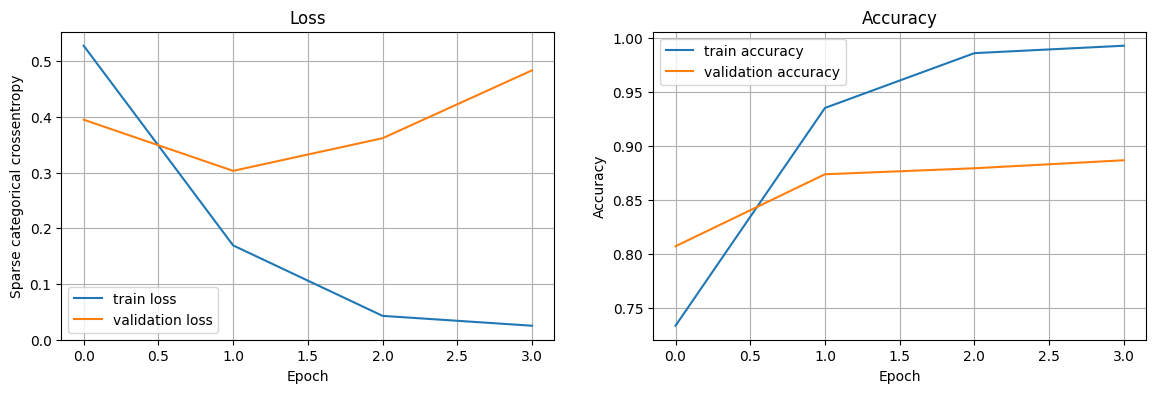

In [29]:
def plot_training_history(history):
    """
    Строит графики loss и accuracy по эпохам.

    Аргументы:
        history: объект keras.callbacks.History, возвращенный model.fit.

    Возвращает:
        None. Функция рисует matplotlib-графики.
    """
    history_frame = pd.DataFrame(history.history)

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))

    axes[0].plot(history_frame["loss"], label="train loss")
    axes[0].plot(history_frame["val_loss"], label="validation loss")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Sparse categorical crossentropy")
    axes[0].legend()
    axes[0].grid(True)

    axes[1].plot(history_frame["accuracy"], label="train accuracy")
    axes[1].plot(history_frame["val_accuracy"], label="validation accuracy")
    axes[1].set_title("Accuracy")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Accuracy")
    axes[1].legend()
    axes[1].grid(True)

    plt.show()


plot_training_history(history)

## 14. Оценка на тестовой выборке

Тестовая выборка не использовалась для обучения и подбора модели. Поэтому она лучше показывает качество на новых данных.

Посмотрим:

- `loss`;
- `accuracy`;
- `classification_report`;
- confusion matrix.

In [30]:
test_loss, test_accuracy = model.evaluate(test_ds, verbose=0)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.4f}")

I0000 00:00:1779799634.377180 3429799 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_19802__.24
I0000 00:00:1779799634.980365 3431606 subprocess_compilation.cc:348] ptxas warning : Registers are spilled to local memory in function 'gemm_fusion_dot_19', 4 bytes spill stores, 4 bytes spill loads



Test loss: 0.2457
Test accuracy: 0.9039


In [31]:
def predict_labels(model, tokens, batch_size):
    """
    Получает предсказанные классы для набора токенизированных текстов.

    Аргументы:
        model: обученная keras.Model.
        tokens: словарь с input_ids и attention_mask.
        batch_size: размер батча для предсказания.

    Возвращает:
        predicted_ids: numpy-массив предсказанных id классов.
        probabilities: numpy-массив вероятностей классов.
    """
    probabilities = model.predict(
        {
            "input_ids": tokens["input_ids"],
            "attention_mask": tokens["attention_mask"],
        },
        batch_size=batch_size,
        verbose=0,
    )

    predicted_ids = np.argmax(probabilities, axis=1)

    return predicted_ids, probabilities


y_pred, y_proba = predict_labels(model, test_tokens, BATCH_SIZE)

target_names = [str(id_to_label[index]) for index in range(NUM_CLASSES)]

print(classification_report(
    y_test,
    y_pred,
    target_names=target_names,
    digits=4,
))

I0000 00:00:1779799637.062498 3429799 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22162__.17
I0000 00:00:1779799638.249017 3429799 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22621__.17


              precision    recall  f1-score   support

           0     0.8182    0.9209    0.8665       215
           1     0.9567    0.8952    0.9250       420

    accuracy                         0.9039       635
   macro avg     0.8875    0.9081    0.8957       635
weighted avg     0.9098    0.9039    0.9052       635



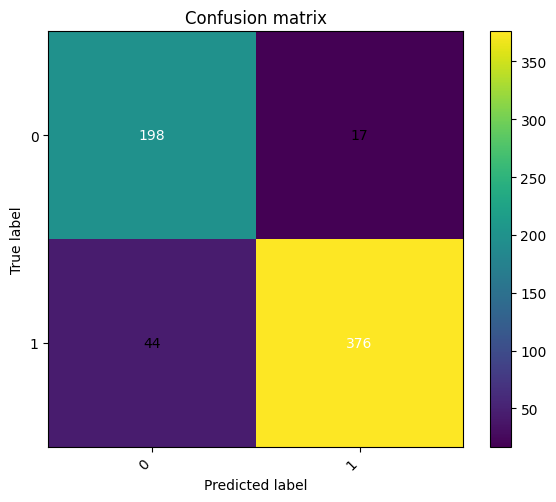

In [32]:
def plot_confusion_matrix(y_true, y_pred, labels):
    """
    Строит confusion matrix для классификации.

    Аргументы:
        y_true: истинные числовые метки.
        y_pred: предсказанные числовые метки.
        labels: список текстовых названий классов в порядке id.

    Возвращает:
        None. Функция рисует matplotlib-график.
    """
    matrix = confusion_matrix(y_true, y_pred)

    fig, ax = plt.subplots(figsize=(6, 5))
    image = ax.imshow(matrix)

    ax.set_title("Confusion matrix")
    ax.set_xlabel("Predicted label")
    ax.set_ylabel("True label")
    ax.set_xticks(np.arange(len(labels)))
    ax.set_yticks(np.arange(len(labels)))
    ax.set_xticklabels(labels, rotation=45, ha="right")
    ax.set_yticklabels(labels)

    for row_index in range(matrix.shape[0]):
        for column_index in range(matrix.shape[1]):
            ax.text(
                column_index,
                row_index,
                matrix[row_index, column_index],
                ha="center",
                va="center",
                color="white" if matrix[row_index, column_index] > matrix.max() / 2 else "black",
            )

    fig.colorbar(image, ax=ax)
    plt.tight_layout()
    plt.show()


plot_confusion_matrix(y_test, y_pred, target_names)

## 15. Инференс на новых фразах

Теперь напишем функцию для предсказания тональности произвольного текста.

Функция:

1. принимает список строк;
2. токенизирует его тем же токенизатором;
3. получает вероятности классов;
4. возвращает удобную таблицу.

In [33]:
def predict_sentiment(texts, model, tokenizer, max_length, id_to_label):
    """
    Предсказывает тональность для новых текстов.

    Аргументы:
        texts: строка или список строк.
        model: обученная keras.Model.
        tokenizer: Hugging Face tokenizer, использованный при обучении.
        max_length: максимальная длина последовательности.
        id_to_label: словарь {id класса: исходная метка}.

    Возвращает:
        pandas DataFrame с текстом, предсказанной меткой и вероятностями классов.
    """
    if isinstance(texts, str):
        texts = [texts]

    tokens = tokenize_texts(texts, tokenizer, max_length)

    probabilities = model.predict(
        {
            "input_ids": tokens["input_ids"],
            "attention_mask": tokens["attention_mask"],
        },
        verbose=0,
    )

    predicted_ids = np.argmax(probabilities, axis=1)

    result = pd.DataFrame({
        "text": texts,
        "predicted_id": predicted_ids,
        "predicted_label": [id_to_label[index] for index in predicted_ids],
        "confidence": np.max(probabilities, axis=1),
    })

    for class_id, class_name in id_to_label.items():
        result[f"probability_{class_name}"] = probabilities[:, class_id]

    return result


demo_texts = [
    "Мне очень понравился этот фильм, отличная работа актеров!",
    "Сервис ужасный, больше никогда сюда не вернусь.",
    "Нормально, но ничего особенного.",
    "Не ожидал, что будет настолько хорошо.",
]

predict_sentiment(demo_texts, model, tokenizer, MAX_LENGTH, id_to_label)

I0000 00:00:1779799641.249152 3429799 dot_merger.cc:481] Merging Dots in computation: a_inference_one_step_on_data_22621__.17


,text,predicted_id,predicted_label,confidence,probability_0,probability_1
0,"Мне очень понравился этот фильм, отличная рабо...",0,0,0.997636,0.997636,0.002364
1,"Сервис ужасный, больше никогда сюда не вернусь.",0,0,0.999410,0.999410,0.000590
2,"Нормально, но ничего особенного.",0,0,0.992739,0.992739,0.007261
3,"Не ожидал, что будет настолько хорошо.",0,0,0.956335,0.956335,0.043665


## 16. Что именно мы построили

Наша модель — не предобученный RuBERT. Мы используем только его токенизатор, а сам классификатор обучаем с нуля.

Это полезно для учебной демонстрации, потому что архитектура видна явно:

- embeddings;
- positional embeddings;
- MultiHeadAttention;
- residual connections;
- LayerNormalization;
- feed-forward network;
- masked pooling;
- softmax classifier.

В промышленной задаче часто берут предобученную модель целиком и дообучают ее:

$$
\mathrm{RuBERT}(x) \rightarrow \mathrm{Classifier}(h_{\mathrm{CLS}}).
$$

Но для понимания архитектуры полезно сначала собрать компактный трансформер самостоятельно.

## 17. Идеи для экспериментов

Попробуйте изменить гиперпараметры и обсудить со студентами результат:

| Параметр | Что изменяет |
|---|---|
| `MAX_LENGTH` | сколько токенов текста видит модель |
| `embed_dim` | размерность представления токенов |
| `num_heads` | число attention-голов |
| `num_layers` | глубину Transformer Encoder |
| `ff_dim` | емкость feed-forward сети |
| `dropout_rate` | силу регуляризации |
| `learning_rate` | скорость обновления весов |